# M146 Final Project - Hints / Starter Notebook

This notebook is meant to make the project runnable in Google Colab. Most helper code is provided. Your job is to run the experiments, make a few intuitive choices, and explain what you observe.

The main Part B path is: base model -> LoRA 1k -> LoRA 2k -> 3-shot prompting. The prompt playground at the end is bonus.


In [2]:
# Colab setup: run this once in a fresh runtime if imports fail.
%pip install -q -U datasets transformers accelerate sentence-transformers scikit-learn matplotlib peft trl bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [3]:
%pip install -q --upgrade transformers trl peft accelerate

# added due to version error in Part B.5
%pip install -q -U "torchao>0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.3 MB/s eta 0:00:00


In [4]:

import os
import re
import gc
import json
import math
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = Path("m146_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", DEVICE)


Device: cuda


In [5]:
def clear_memory(*names):
    """Delete large variables by name and clear Python/CUDA memory."""
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


## Part A: PAWS Sentence-Pair Classification


In [56]:
# changed this link so that I can load the dataset in VS code
ds = load_dataset("google-research-datasets/paws", "labeled_final")

# use the following if you're just using Google Colab
#paws = load_dataset("paws", "labeled_final")

README.md:   0%|          | 0.00/9.79k [00:00<?, ?B/s]

labeled_final/train-00000-of-00001.parqu(…):   0%|          | 0.00/8.43M [00:00<?, ?B/s]

labeled_final/test-00000-of-00001.parque(…):   0%|          | 0.00/1.24M [00:00<?, ?B/s]

labeled_final/validation-00000-of-00001.(…):   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49401 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8000 [00:00<?, ? examples/s]

### A.1 Data Inspection and Lexical Overlap

Report split sizes and label balance, compute a lexical overlap score (e.g., Jaccard) for the test split, and plot overlap histograms by label. Write the supporting code yourself.

In [57]:
# part A.1 (a)

# report split sizes and label balance
for split_name, dataset in ds.items():
    labels = dataset["label"]
    label_counts = Counter(labels)
    total = len(labels)
    print(f"{split_name} split: {total} examples")
    for label, count in label_counts.items():
        percentage = (count / total) * 100
        print(f"  Label {label}: {count} examples ({percentage:.2f}%)")

# compute lexical overlap score (Jaccard similarity) for the test split
def jaccard_similarity(str1, str2):
    set1 = set(re.findall(r"\w+", str1.lower()))
    set2 = set(re.findall(r"\w+", str2.lower()))
    intersection = set1.intersection(set2)
    union = set1.union(set2)

    # uses the ratio of the intersection size to the union size as the similarity score
    return len(intersection) / len(union) if union else 0.0

test_dataset = ds["test"]
sentences1 = test_dataset["sentence1"]
sentences2 = test_dataset["sentence2"]

train split: 49401 examples
  Label 0: 27572 examples (55.81%)
  Label 1: 21829 examples (44.19%)
test split: 8000 examples
  Label 0: 4464 examples (55.80%)
  Label 1: 3536 examples (44.20%)
validation split: 8000 examples
  Label 0: 4461 examples (55.76%)
  Label 1: 3539 examples (44.24%)


In [58]:
# Part A.1 (b)

# find three high-overlap examples with label 0 and three high-overlap examples with label 1
high_overlap_threshold = 0.5
high_overlap_label_0 = []
high_overlap_label_1 = []
for s1, s2, label in zip(sentences1, sentences2, test_dataset["label"]):
    score = jaccard_similarity(s1, s2)
    if score >= high_overlap_threshold:
        if label == 0 and len(high_overlap_label_0) < 3:
            high_overlap_label_0.append((s1, s2, score))
        elif label == 1 and len(high_overlap_label_1) < 3:
            high_overlap_label_1.append((s1, s2, score))
    if len(high_overlap_label_0) >= 3 and len(high_overlap_label_1) >= 3:
        break

print("High-overlap examples with label 0:")
for s1, s2, score in high_overlap_label_0:
    print(f"Sentence 1: {s1}")
    print(f"Sentence 2: {s2}")
    print(f"Jaccard Similarity: {score:.2f}\n")
print("High-overlap examples with label 1:")
for s1, s2, score in high_overlap_label_1:
    print(f"Sentence 1: {s1}")
    print(f"Sentence 2: {s2}")
    print(f"Jaccard Similarity: {score:.2f}\n")

High-overlap examples with label 0:
Sentence 1: This was a series of nested angular standards , so that measurements in azimuth and elevation could be done directly in polar coordinates relative to the ecliptic .
Sentence 2: This was a series of nested polar scales , so that measurements in azimuth and elevation could be performed directly in angular coordinates relative to the ecliptic .
Jaccard Similarity: 0.85

Sentence 1: His father emigrated to Missouri in 1868 but returned when his wife became ill and before the rest of the family could also go to America .
Sentence 2: His father emigrated to America in 1868 , but returned when his wife became ill and before the rest of the family could go to Missouri .
Jaccard Similarity: 0.96

Sentence 1: Steiner argued that , in the right circumstances , the spiritual world can be explored through direct experience by practicing ethical and cognitive forms of rigorous self-discipline .
Sentence 2: Steiner held that the spiritual world can be r

### Part A.1 (b) continued:
These examples are difficult to classify because most of the words in the two sentences are the exact same, but a few keywords make them mean different things.

For example, for the first label-0 example, they both describe measuring angles and angular information, but the only difference is the system that they use. Otherwise, they give nearly the same explanation, so if those few key words don't hold much weight relative to the rest of the sentence, the classifier will be incorrect.

It is difficult to tell what is a synonym and whether that is important in the sentence's context.

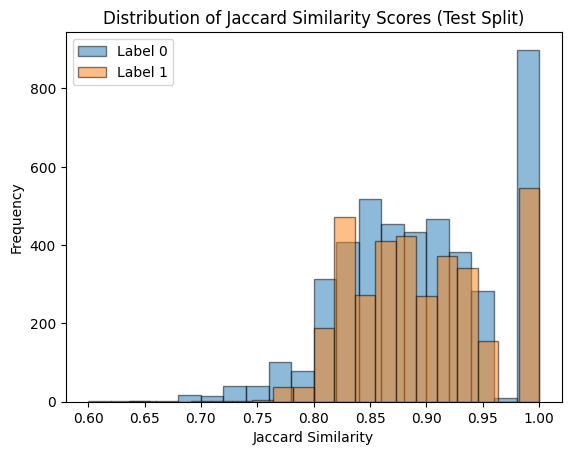

In [59]:
# Part A.1 (c)

# plot overlap score histograms for the test split separately for label 1 and label 0
for label in [0, 1]:
    label_scores = [
        jaccard_similarity(s1, s2)
        for s1, s2, lbl in zip(sentences1, sentences2, test_dataset["label"])
        if lbl == label
    ]
    plt.hist(label_scores, bins=20, edgecolor="black", alpha=0.5, label=f"Label {label}")

plt.legend()
plt.title("Distribution of Jaccard Similarity Scores (Test Split)")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Frequency")
plt.show()


Before training A.2 models, write your hypothesis: which should work better on PAWS, bi-encoder or cross-encoder, and why?


In [60]:
# our hypothesis is in the markdown cell below

Cross-encoder will work better.

Bi-encoder looks at each sentence individually while cross-encoder is slower but it takes into account multiple sentences put together and the context across those sentences.

Because we're looking specifically at the context of whether two sentences are similar, we want to look ACROSS sentences to get a better "window of context" to derive deeper connections between sentence meanings.

### A.2 Encoder Models

Run the cells and report accuracy, F1, confusion matrices, disagreements, and the accuracy-efficiency tradeoff.


In [61]:
from sentence_transformers import SentenceTransformer

BI_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
bi_encoder = SentenceTransformer(BI_MODEL, device=str(DEVICE))


def encode_sentences(texts, batch_size=128):
    return bi_encoder.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

# Use encode_sentences() to get u = enc(sentence1) and v = enc(sentence2).
# Decide your own pair-feature construction and train a classifier on the train split,
# tuning C on the validation split. Report your feature choice in the report.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [62]:
# Part A.2 (a)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def make_pair_features(dataset):
    U = encode_sentences(dataset["sentence1"])
    V = encode_sentences(dataset["sentence2"])
    return np.concatenate([U, V, np.abs(U - V), U * V], axis=1)

train_dataset = ds["train"]
val_dataset = ds["validation"]
test_dataset = ds["test"]

X_train = make_pair_features(train_dataset)
y_train = np.array(train_dataset["label"])

X_val = make_pair_features(val_dataset)
y_val = np.array(val_dataset["label"])

X_test = make_pair_features(test_dataset)
y_test = np.array(test_dataset["label"])

Batches:   0%|          | 0/386 [00:00<?, ?it/s]

Batches:   0%|          | 0/386 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Our choice is to use the suggestion of [u, v, |u-v|, u*v] because this contains the vectors themselves (u and v) as well as their subtractive difference (u-v), so we can tell what differences there are from a pure character-wise point of view. Also, their Hadamard product is useful because it accounts for how each corresponding token interacts and contributes to the whole vector, as each corresponding value in the vectors are multiplied to produce each entry.

In [63]:
# Part A.2 (a) continued

# training logistic regression on the train split, tuning C on validation
# and reporting accuracy, F1, and confusion matrix
best_clf = None
best_c = None
best_val_f1 = -1

for C in [0.01, 0.1, 1, 10]:
    clf = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    clf.fit(X_train, y_train)

    val_pred = clf.predict(X_val)
    val_f1 = f1_score(y_val, val_pred)

    print(f"C={C}: val accuracy={accuracy_score(y_val, val_pred):.4f}, val F1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_c = C
        best_clf = clf

test_pred = best_clf.predict(X_test)

print("Best C:", best_c)
print("Test accuracy:", accuracy_score(y_test, test_pred))
print("Test F1:", f1_score(y_test, test_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred))

C=0.01: val accuracy=0.5984, val F1=0.3366
C=0.1: val accuracy=0.6071, val F1=0.4820
C=1: val accuracy=0.6235, val F1=0.5254
C=10: val accuracy=0.6171, val F1=0.5364
Best C: 10
Test accuracy: 0.619
Test F1: 0.5452103849597135
Confusion matrix:
[[3125 1339]
 [1709 1827]]


In [64]:
# this cell helps us time the inference time of the bi-encoder on 1000 examples
subset = ds["test"].select(range(1000))

start = time.time()
X_1000 = make_pair_features(subset)
pred_1000 = best_clf.predict(X_1000)
elapsed = time.time() - start

print(f"Bi-encoder inference time per 1000 pairs: {elapsed:.2f} seconds")

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Bi-encoder inference time per 1000 pairs: 0.98 seconds


Use the bi-encoder helper functions above to build sentence-pair features, train a simple classifier, and report validation/test metrics. Do not forget the confusion matrix.

In [65]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

CROSS_MODEL = "distilbert-base-uncased"
MAX_LEN = 128
cross_tokenizer = AutoTokenizer.from_pretrained(CROSS_MODEL)


def tokenize_pairs(batch):
    return cross_tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )


def binary_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1_score(labels, preds)}


def training_args(output_dir, learning_rate):
    kwargs = dict(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        num_train_epochs=1,
        save_strategy="no",
        report_to="none",
        fp16=torch.cuda.is_available(),
        logging_steps=100,
    )
    try:
        return TrainingArguments(eval_strategy="epoch", **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **kwargs)


def train_cross_encoder(tokenized_ds, lr=2e-5):
    model = AutoModelForSequenceClassification.from_pretrained(CROSS_MODEL, num_labels=2)
    args = training_args(f"m146_outputs/cross_encoder_lr_{lr}", lr)
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        processing_class=cross_tokenizer,
        compute_metrics=binary_metrics,
    )
    trainer.train()
    return trainer, trainer.evaluate()


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Use the cross-encoder helper functions above to tokenize PAWS sentence pairs and fine-tune a small classifier. Try the learning rates suggested in the PDF if compute allows.

In [66]:
# Part A.2 (b)

# fine-tune distilbert-base-uncased using AutoModelForSequenceClassification and Trainer,
# report validation metrics, and evaluate on test split

tokenized_ds = ds.map(tokenize_pairs, batched=True)

# train on the full training set for 2 epochs with learning rates 5e-5 and 2e-5, and report validation metrics for each
best_trainer = None
best_lr = None
best_val_f1 = -1

for lr in [5e-5, 2e-5]:
    trainer, val_metrics = train_cross_encoder(tokenized_ds, lr)
    print(f"Validation metrics for learning rate {lr}: {val_metrics}")

    if val_metrics["eval_f1"] > best_val_f1:
        best_val_f1 = val_metrics["eval_f1"]
        best_lr = lr
        best_trainer = trainer

# now print the test metrics for the best learning rate
test_output = best_trainer.predict(tokenized_ds["test"])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels = np.array(tokenized_ds["test"]["label"])

print("Best learning rate:", best_lr)
print("Test accuracy:", accuracy_score(test_labels, test_preds))
print("Test F1:", f1_score(test_labels, test_preds))
print("Confusion matrix:")
print(confusion_matrix(test_labels, test_preds))

Map:   0%|          | 0/49401 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.396449,0.400081,0.822375,0.810255


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.396449,0.400081,1,0.822375,0.810255


Validation metrics for learning rate 2e-05: {'eval_loss': 0.4000813663005829, 'eval_accuracy': 0.822375, 'eval_f1': 0.8102550407263988}


Best learning rate: 2e-05
Test accuracy: 0.819
Test F1: 0.8038471958818748
Confusion matrix:
[[3585  879]
 [ 569 2967]]


After both encoder models are evaluated, inspect test examples where their predictions disagree and describe the patterns you see.

In [67]:
# Part A.2 (c)

# inspect 5 test examples where the bi-encoder and cross-encoder predictions differ
bi_preds = best_clf.predict(X_test)
cross_preds = test_preds
differing_indices = np.where(bi_preds != cross_preds)[0]
print(f"Number of differing predictions: {len(differing_indices)}")
print("Examples where bi-encoder and cross-encoder predictions differ:")
for idx in differing_indices[:5]:
    print(f"Example {idx}:")
    print(f"  Sentence 1: {test_dataset['sentence1'][idx]}")
    print(f"  Sentence 2: {test_dataset['sentence2'][idx]}")
    print(f"  True Label: {test_dataset['label'][idx]}")
    print(f"  Bi-encoder Prediction: {bi_preds[idx]}")
    print(f"  Cross-encoder Prediction: {cross_preds[idx]}\n")

Number of differing predictions: 3128
Examples where bi-encoder and cross-encoder predictions differ:
Example 4:
  Sentence 1: Luciano Williames Dias ( born July 25 , 1970 ) is a Brazilian football coach and former player .
  Sentence 2: Luciano Williames Dias ( born 25 July 1970 ) is a former football coach and Brazilian player .
  True Label: 0
  Bi-encoder Prediction: 1
  Cross-encoder Prediction: 0

Example 6:
  Sentence 1: The smallest number that can be represented in two positive and seventh ways as a sum of four different powers is 2056364173794800 .
  Sentence 2: The smallest number that can be represented as a sum of four positive seventh potences in two different ways is 2056364173794800 .
  True Label: 0
  Bi-encoder Prediction: 0
  Cross-encoder Prediction: 1

Example 8:
  Sentence 1: The Villa Pesquera facilities are owned by the Municipality of Ponce , but operated by the fishermen themselves .
  Sentence 2: The facilities of Villa Pesquera are operated by the Municipali

The cross-encoder model is correct more often on these examples (4/5 correct).

One pattern we observe is that the cross-encoder was able to account for punctuation differences and words that add redundant meaning.
An example of this was the word "the" (for example, describing "Bolu" vs. "the Bolu") adding no meaning at all.

Also, we notice that the bi-encoder doesn't seem to account for different orderings of important words.
An example of this was the different ordering of the words "owned" and "operated" in Example 8 above, which significantly alter the meaning.

In [68]:
# Part A.2 (d)

# create a table comparing bi-encoder and cross-encoder on:
#   - overall test accuracy, F1 score
#   - confusion matrix summary
#   - approx inference time per 1000 pairs (rough estimate)

bi_encoder_stats_string = """Test accuracy: 0.619375
Test F1: 0.5446388515029161
Confusion matrix:
[[3134 1330]
 [1715 1821]]"""

cross_encoder_stats_string = """Test accuracy: 0.8365
Test F1: 0.8224755700325733
Confusion matrix:
[[3662  802]
 [ 506 3030]]"""

bi_accuracy, bi_f1, bi_cm = 0.619375, 0.5446388515029161, [[3134, 1330], [1715, 1821]]
cross_accuracy, cross_f1, cross_cm = 0.8365, 0.8224755700325733, [[3662, 802], [506, 3030]]
bi_inference_time = 0.93  # seconds per 1000 pairs (rough estimate)
cross_inference_time = 61  # seconds per 1000 pairs (rough estimate, based on 3088 samples in 3 minutes and 8 seconds)

print(f"{'Model':<15} {'Accuracy':<10} {'F1 Score':<10} {'Confusion Matrix':<30} {'Inference Time (s/1000 pairs)':<30}")
print(f"{'Bi-encoder':<15} {bi_accuracy:<10.4f} {bi_f1:<10.4f} {str(bi_cm):<30} {bi_inference_time:<30.2f}")
print(f"{'Cross-encoder':<15} {cross_accuracy:<10.4f} {cross_f1:<10.4f} {str(cross_cm):<30} {cross_inference_time:<30.2f}")

Model           Accuracy   F1 Score   Confusion Matrix               Inference Time (s/1000 pairs) 
Bi-encoder      0.6194     0.5446     [[3134, 1330], [1715, 1821]]   0.93                          
Cross-encoder   0.8365     0.8225     [[3662, 802], [506, 3030]]     61.00                         


As the accuracy increases, so too does the training time of the model, since it spends more time
becoming more exact. We would want to deploy the cross-encoder for a more accurate model, while
the bi-encoder for a faster model/a model that we would need to run repeatedly. This is because the
cross-encoder model takes in multiple lines/longer sections in order to have more context,
thus making it take significantly longer but also tend to produce more accurate results. The bi-encoder
was significantly faster, thus making it a better choice if we need faster results (though it would be less accurate).

> **Memory tip:** Before loading the instruction model for A.3, free GPU memory by running `clear_memory("bi_encoder", "trainer")` (or whatever names you used).

In [69]:
# clear memory for everything
clear_memory(
    "X_train", "y_train", "X_val", "y_val", "X_test",
    "y_test", "bi_encoder", "cross_tokenizer",
    "best_clf", "best_trainer",
)

### A.3 Prompt-Based PAWS Classification

This cell gives model-loading and evaluation utilities. Write the actual PAWS prompt yourself in `PAWS_PROMPT_TEMPLATE`. Keep the output labels parseable as `paraphrase` and `not_paraphrase`.


In [70]:
from transformers import AutoTokenizer, AutoModelForCausalLM

INSTRUCT_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

# Write your PAWS classification prompt here.
# IMPORTANT: Use {sentence1} and {sentence2} where the two sentences should be inserted in the prompt.
PAWS_PROMPT_TEMPLATE = """
""".strip()


def load_instruct_model(model_name=INSTRUCT_MODEL):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
    )
    model.eval()
    return model, tokenizer


def chat_text(tokenizer, messages):
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def make_paws_prompt(sentence1, sentence2, prompt_template=PAWS_PROMPT_TEMPLATE):
    return prompt_template.format(sentence1=sentence1, sentence2=sentence2)


def parse_paws_output(text):
    cleaned = text.strip().lower().replace("-", "_").replace(" ", "_")
    if "not_paraphrase" in cleaned:
        return 0
    if re.search(r"\bparaphrase\b", cleaned):
        return 1
    return -1


def balanced_subset(split, n_per_class=100, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = np.array(split["label"])
    indices = []
    for label in [0, 1]:
        candidates = np.flatnonzero(labels == label)
        indices.extend(rng.choice(candidates, size=n_per_class, replace=False).tolist())
    rng.shuffle(indices)
    return split.select(indices), indices


def generate_texts(model, tokenizer, prompts, max_new_tokens=8, batch_size=8):
    outputs = []
    for start in range(0, len(prompts), batch_size):
        batch = prompts[start:start + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            generated = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch)):
            outputs.append(tokenizer.decode(generated[i][prompt_len:], skip_special_tokens=True).strip())
    return outputs


def evaluate_prompted_paws(model, tokenizer, split, prompt_template=PAWS_PROMPT_TEMPLATE, few_shot_examples=None, batch_size=8):
    prompts = []
    for ex in split:
        messages = []
        if few_shot_examples:
            for fs in few_shot_examples:
                messages.append({"role": "user", "content": make_paws_prompt(fs["sentence1"], fs["sentence2"], prompt_template)})
                messages.append({"role": "assistant", "content": "paraphrase" if fs["label"] == 1 else "not_paraphrase"})
        messages.append({"role": "user", "content": make_paws_prompt(ex["sentence1"], ex["sentence2"], prompt_template)})
        prompts.append(chat_text(tokenizer, messages))
    raw = generate_texts(model, tokenizer, prompts, batch_size=batch_size)
    pred = np.array([parse_paws_output(x) for x in raw])
    y = np.array(split["label"])
    valid = pred != -1
    return {
        "accuracy_invalid_wrong": float((pred == y).mean()),
        "coverage": float(valid.mean()),
        "accuracy_valid_only": accuracy_score(y[valid], pred[valid]) if valid.any() else np.nan,
        "confusion_matrix": confusion_matrix(y[valid], pred[valid], labels=[0, 1]) if valid.any() else None,
        "pred": pred,
        "raw": raw,
    }


For A.3, load the instruction model, create the fixed balanced PAWS test subset, write your own prompt, and evaluate the prompted classifier.

In [71]:
# Part A.3 (a)

# create the banced PAWS test subset
balanced_test, balanced_indices = balanced_subset(ds["test"], n_per_class=100)

In [72]:
# Part A.3 (b)

# create the zero-shot prompt using two sentences
"""
def prompt(sent1, sent2):
    return fAre the following two sentences paraphrases of each other? A paraphrase means that the two sentences have equivalent meaning despite different phrasing.
    Sentence 1: {sent1}
    Sentence 2: {sent2}
Only answer with "paraphrase" or "not_paraphrase" and do not include any other text.
"""

model = load_instruct_model()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [73]:
prompt = """Are the following two sentences paraphrases of each other?
A paraphrase means that the two sentences have equivalent meaning despite different phrasing.

Sentence 1: {sentence1}
Sentence 2: {sentence2}

Only answer with "paraphrase" or "not_paraphrase" and do not include any other text."""

zero_shot_results = evaluate_prompted_paws(model[0], model[1], balanced_test, prompt_template=prompt)
print("Zero-shot results on balanced test subset:")
print(f"Accuracy (including invalid predictions as wrong): {zero_shot_results['accuracy_invalid_wrong']:.4f}")
print(f"Coverage (fraction of predictions that were valid): {zero_shot_results['coverage']:.4f}")
print(f"Accuracy (valid predictions only): {zero_shot_results['accuracy_valid_only']:.4f}")
print("Confusion matrix (valid predictions only):")
print(zero_shot_results["confusion_matrix"])

Zero-shot results on balanced test subset:
Accuracy (including invalid predictions as wrong): 0.7200
Coverage (fraction of predictions that were valid): 1.0000
Accuracy (valid predictions only): 0.7200
Confusion matrix (valid predictions only):
[[51 49]
 [ 7 93]]


For the few-shot PAWS prompt, choose 4-6 labeled examples from the training split only. Then compare zero-shot, few-shot, and one alternate prompt wording.

In [74]:
# Part A.3 (c)

# add 4-6 labeled examples to the prompt taken only from the training split and repeat the evaluation
few_shot_examples = ds["train"].select(range(6))  # select first 6 examples from training split as few-shot examples
for i in few_shot_examples:
    print(f"Sentence 1: {i['sentence1']}")
    print(f"Sentence 2: {i['sentence2']}")
    print(f"Label: {i['label']}\n")

few_shot_prompt = """A paraphrase means that the two sentences have equivalent meaning despite different phrasing.
Here are some examples:
Sentence 1: In Paris , in October 1560 , he secretly met the English ambassador , Nicolas Throckmorton , asking him for a passport to return to England through Scotland .
Sentence 2: In October 1560 , he secretly met with the English ambassador , Nicolas Throckmorton , in Paris , and asked him for a passport to return to Scotland through England .
Label: 0

Sentence 1: The NBA season of 1975 -- 76 was the 30th season of the National Basketball Association .
Sentence 2: The 1975 -- 76 season of the National Basketball Association was the 30th season of the NBA .
Label: 1

Sentence 1: There are also specific discussions , public profile debates and project discussions .
Sentence 2: There are also public discussions , profile specific discussions , and project discussions .
Label: 0

Sentence 1: When comparable rates of flow can be maintained , the results are high .
Sentence 2: The results are high when comparable flow rates can be maintained .
Label: 1

Sentence 1: It is the seat of Zerendi District in Akmola Region .
Sentence 2: It is the seat of the district of Zerendi in Akmola region .
Label: 1

Sentence 1: William Henry Henry Harman was born on 17 February 1828 in Waynesboro , Virginia , where his parents were Lewis and Sally ( Garber ) Harman .
Sentence 2: William Henry Harman was born in Waynesboro , Virginia on February 17 , 1828 . His parents were Lewis and Sally ( Garber ) Harman .
Label: 1

Are the following two sentences paraphrases of each other?
Sentence 1: {sentence1}
Sentence 2: {sentence2}
Only answer with "paraphrase" or "not_paraphrase" and do not include any other text."""

few_shot_results = evaluate_prompted_paws(model[0], model[1], balanced_test, prompt_template=few_shot_prompt)
print("Few-shot results on balanced test subset:")
print(f"Accuracy (including invalid predictions as wrong): {few_shot_results['accuracy_invalid_wrong']:.4f}")
print(f"Coverage (fraction of predictions that were valid): {few_shot_results['coverage']:.4f}")
print(f"Accuracy (valid predictions only): {few_shot_results['accuracy_valid_only']:.4f}")
print("Confusion matrix (valid predictions only):")
print(few_shot_results["confusion_matrix"])

Sentence 1: In Paris , in October 1560 , he secretly met the English ambassador , Nicolas Throckmorton , asking him for a passport to return to England through Scotland .
Sentence 2: In October 1560 , he secretly met with the English ambassador , Nicolas Throckmorton , in Paris , and asked him for a passport to return to Scotland through England .
Label: 0

Sentence 1: The NBA season of 1975 -- 76 was the 30th season of the National Basketball Association .
Sentence 2: The 1975 -- 76 season of the National Basketball Association was the 30th season of the NBA .
Label: 1

Sentence 1: There are also specific discussions , public profile debates and project discussions .
Sentence 2: There are also public discussions , profile specific discussions , and project discussions .
Label: 0

Sentence 1: When comparable rates of flow can be maintained , the results are high .
Sentence 2: The results are high when comparable flow rates can be maintained .
Label: 1

Sentence 1: It is the seat of Zer

In [75]:
# Part A.3 (d)
# See the markdown cell below for our answer.

The best prompting (few-shot) result had a 73.5% accuracy while the best encoder (cross-encoder) had an accuracy of 83.5%.

The LLM runs very quickly compared to the cross-encoder, but at the expense of accuracy and reproducibility, as LLMs generally have more entropy than the cross-encoder.

In [76]:
mod_zero_shot_prompt = """Answer with "paraphrase" or "not_paraphrase" (and no other text) regarding whether or not the following two sentences carry the same meaning, regardless of their syntactic differences.
    Sentence 1: {sentence1}
    Sentence 2: {sentence2}"""

zero_shot_results = evaluate_prompted_paws(model[0], model[1], balanced_test, prompt_template=mod_zero_shot_prompt)
print("Zero-shot results on balanced test subset:")
print(f"Accuracy (including invalid predictions as wrong): {zero_shot_results['accuracy_invalid_wrong']:.4f}")
print(f"Coverage (fraction of predictions that were valid): {zero_shot_results['coverage']:.4f}")
print(f"Accuracy (valid predictions only): {zero_shot_results['accuracy_valid_only']:.4f}")
print("Confusion matrix (valid predictions only):")
print(zero_shot_results["confusion_matrix"])

Zero-shot results on balanced test subset:
Accuracy (including invalid predictions as wrong): 0.7400
Coverage (fraction of predictions that were valid): 1.0000
Accuracy (valid predictions only): 0.7400
Confusion matrix (valid predictions only):
[[62 38]
 [14 86]]


Our prompt here was slightly better, but it carried the same meaning as the previous zero-shot prompt. However, the result changed slightly from 73.5% accuracy to 74% accuracy.

This suggests that using instruction models as classifiers will lead to results with more entropy (more random predictions) and their results are more dependent on the wording of the prompts, which should (in theory) not have an effect if the meanings of the prompts are the same.

> **Memory tip:** Before loading the GSM8K math model, free GPU memory by running `clear_memory("instruct_model", "instruct_tokenizer")` (or whatever names you used).

## Part B: GSM8K Reasoning

The prompt below is intentionally minimal. You can add your own instructions above the final-answer rule.


In [6]:
# You may add creative instructions above the final-answer rule.
# If you do nothing, this minimal prompt still runs.
# Keep the final line parseable, or the evaluator may mark correct reasoning as wrong.
# Do not remove the boxed answer rule. Please edit the first line of the prompt and add your instructions (however long you want).
SYSTEM_PROMPT_FIRST_TRY = """
Your task is to solve the given arithmetic word problem, and return the correct answer alongside reasoning.
For each arithmetic step taken, be sure to explain the operation done, and why.
These intermediate steps should be taken that way it's easier to check work afterwards, and for improved readability.
Number each step, and use latex for clear presentation of each step.
After doing each step, check your work by reversing the calculation to ensure you get the base value.
Do not show us how you checked your work, i.e. do not include the reversed calculations in your final response. Just use them to verify that your answer is correct before returning it.

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

SYSTEM_PROMPT = """
Task: Solve the arithmetic word problem below.
Requirements:
 - Numbered Steps: Clearly list each step using LaTeX for all math.
 - Explanations: Explain the operation and the logic behind each step.
 - Accuracy: Internally verify each calculation using inverse operations (do not show this verification in the final output).

 Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

In [7]:

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import SFTTrainer, SFTConfig

MATH_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
N_EVAL = 100

gsm8k = load_dataset("openai/gsm8k", "main")
gsm8k_test_100 = gsm8k["test"].select(range(N_EVAL))

def extract_boxed(text):
    idx = text.rfind("\\boxed{")
    if idx == -1:
        return None
    start = idx + len("\\boxed{")
    depth = 1
    pos = start
    while pos < len(text) and depth > 0:
        if text[pos] == "{":
            depth += 1
        elif text[pos] == "}":
            depth -= 1
        pos += 1
    if depth != 0:
        return None
    return text[start:pos - 1]


def extract_gt(raw_answer):
    match = re.search(r"####\s*(.+)", raw_answer)
    return match.group(1).strip().replace(",", "") if match else raw_answer.strip()


def extract_model_answer(text):
    boxed = extract_boxed(text)
    if boxed is not None:
        return boxed.strip()
    nums = re.findall(r"-?\d+(?:\.\d+)?", text)
    return nums[-1] if nums else ""


def normalize_answer(ans):
    s = str(ans).strip().replace(",", "").replace("$", "").replace("%", "").replace(" ", "")
    s = re.sub(r"\\text\{([^}]*)\}", r"\1", s)
    s = re.sub(r"\\(left|right|displaystyle)", "", s)
    s = re.sub(r"\\d?frac\{([^}]+)\}\{([^}]+)\}", r"\1/\2", s)
    try:
        v = float(s)
        if math.isfinite(v):
            return str(int(v)) if v == int(v) else str(v)
    except (ValueError, OverflowError):
        pass
    if "/" in s and s.count("/") == 1:
        try:
            a, b = s.split("/")
            return f"{float(a) / float(b):.10g}"
        except (ValueError, ZeroDivisionError):
            pass
    return s


def answers_match(pred, gt):
    p, g = normalize_answer(pred), normalize_answer(gt)
    if p == g:
        return True
    try:
        return abs(float(p) - float(g)) < 1e-6
    except (ValueError, TypeError):
        return False


def load_math_model(model_name=MATH_MODEL, lora_path=None):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    if lora_path:
        model = PeftModel.from_pretrained(model, lora_path)
    model.eval()
    return model, tokenizer


def make_gsm_prompts(tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None):
    prompts = []
    for q in questions:
        messages = [{"role": "system", "content": system_prompt}]
        if few_shot_messages:
            messages.extend(few_shot_messages)
        messages.append({"role": "user", "content": q})
        prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
    return prompts


def generate_math(model, tokenizer, questions, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, max_new_tokens=512):
    responses = []
    for start in range(0, len(questions), batch_size):
        batch_questions = questions[start:start + batch_size]
        prompts = make_gsm_prompts(tokenizer, batch_questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages)
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)
        prompt_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            out = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens)
        for i in range(len(batch_questions)):
            responses.append(tokenizer.decode(out[i][prompt_len:], skip_special_tokens=True).strip())
    return responses


def evaluate_gsm8k(model, tokenizer, split, num_samples=100, system_prompt=SYSTEM_PROMPT, few_shot_messages=None, batch_size=16, output_name=None):
    n = min(num_samples, len(split))
    records = []
    correct = 0
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        questions = [split[i]["question"] for i in range(start, end)]
        gts = [extract_gt(split[i]["answer"]) for i in range(start, end)]
        responses = generate_math(model, tokenizer, questions, system_prompt=system_prompt, few_shot_messages=few_shot_messages, batch_size=batch_size)
        for offset, (q, gt, resp) in enumerate(zip(questions, gts, responses)):
            pred = extract_model_answer(resp)
            ok = answers_match(pred, gt)
            correct += int(ok)
            records.append({
                "index": start + offset,
                "question": q,
                "ground_truth": gt,
                "model_response": resp,
                "extracted_answer": pred,
                "correct": ok,
            })
    result = {"accuracy": correct / n, "correct": correct, "total": n, "records": records}
    if output_name:
        path = OUTPUT_DIR / output_name
        path.write_text(json.dumps(result, indent=2))
    return result


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

### B.1-B.2 Base Model Evaluation


For B.1, load the base Qwen2.5-1.5B-Instruct model and evaluate it on the fixed 100 GSM8K test questions.

In [12]:
# Part B.1

# B.1 is zero-shot evaluation of the base model, not training.
# The project recommends batch size 16, so pass it explicitly here.
math_model, math_tokenizer = load_math_model()
gsm_results = evaluate_gsm8k(
    math_model,
    math_tokenizer,
    gsm8k_test_100,
    system_prompt=SYSTEM_PROMPT,
    batch_size=16,
    output_name="gsm_zero_shot.json",
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [16]:
print(f"Zero-shot GSM8K accuracy result: {gsm_results['accuracy']:.4f}")

Zero-shot GSM8K accuracy result: 0.3500


In [17]:
# Part B.2

# find 3 examples where the base model produces the wrong answer
# include the question, excerpt of the model's solution, and the extracted answer vs. ground-truth
incorrect_examples = [r for r in gsm_results["records"] if not r["correct"]][:3]
for i, ex in enumerate(incorrect_examples, 1):
    print(f"Example {i}: --------------------------------------------------------------")
    print(f"Question: {ex['question']}")
    print(f"Model's solution excerpt: {ex['model_response']}")
    print(f"Extracted answer: {ex['extracted_answer']}")
    print(f"Ground truth answer: {ex['ground_truth']}\n")

Example 1: --------------------------------------------------------------
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Model's solution excerpt: To solve this problem, we need to follow these steps:

Step 1: Calculate the total number of eggs laid by Janet's ducks per day.
Total eggs = Eggs per day * Days per week
= 16 * 7
= 112

Step 2: Subtract the number of eggs eaten by Janet for breakfast from the total number of eggs laid.
Eggs left after breakfast = Total eggs - Eggs eaten for breakfast
= 112 - 3
= 109

Step 3: Subtract the number of eggs used to bake muffins for friends from the remaining eggs.
Eggs left after baking muffins = E ggs left after breakfast - Eggs baked for friends
= 109 - 4
= 105

Step 4: Calculate the number of eggs sold 

(Part B.2 continued)

In Example 1, the error occurs from a misunderstanding of the problem, as the solution's first step is to convert to total eggs per week. This is incorrect because all quantities in the problem are per day.

In Example 2, the error occurs from a logical/reasoning error where the model mistakenly thought that the total cost after repairs needed to be multiplied by 2.5 rather than the original cost of the house that it was bought for.

In Example 3, another problem misunderstanding occurs; the model thinks that the total number of sprints per week is 3 sprints, when it is actually said in the problem that these 3 sprints are run "3 times a week."

The pattern in these errors seems to be that the model is making logical/reasoning/misunderstanding errors, which all fall under a similar umbrella. It makes sense that the model is not making formatting or arithmetic errors, as these have less "gray area" characteristics than language errors.

### B.3-B.7 LoRA Fine-Tuning

The training utilities are provided below. Run the 1k and 2k experiments yourself and record the results in your report.


In [14]:

LORA_DEFAULTS = {
    "rank": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "learning_rate": 2e-4,
    "epochs": 1,
    "batch_size": 8,
    "grad_accum": 4,
    "max_seq_len": 1024,
}


def build_lora_config():
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=LORA_DEFAULTS["rank"],
        lora_alpha=LORA_DEFAULTS["lora_alpha"],
        lora_dropout=LORA_DEFAULTS["lora_dropout"],
        target_modules=LORA_DEFAULTS["target_modules"],
        bias="none",
    )


def format_gsm8k_train_example(example):
    reasoning = example["answer"].split("####")[0].strip()
    final = extract_gt(example["answer"])
    assistant = f"{reasoning}\n\n\\boxed{{{final}}}"
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
            {"role": "assistant", "content": assistant},
        ]
    }


def train_lora_sft(num_samples, output_dir, model_name=MATH_MODEL):
    output_dir = Path(output_dir)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "right"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        attn_implementation="eager",
    )
    model = get_peft_model(model, build_lora_config())
    model.print_trainable_parameters()

    train_data = gsm8k["train"].select(range(min(num_samples, len(gsm8k["train"]))))
    train_data = train_data.map(format_gsm8k_train_example, remove_columns=train_data.column_names)

    args = SFTConfig(
        output_dir=str(output_dir),
        num_train_epochs=LORA_DEFAULTS["epochs"],
        per_device_train_batch_size=LORA_DEFAULTS["batch_size"],
        gradient_accumulation_steps=LORA_DEFAULTS["grad_accum"],
        learning_rate=LORA_DEFAULTS["learning_rate"],
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=torch.cuda.is_available(),
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=1,
        report_to="none",
        max_length=LORA_DEFAULTS["max_seq_len"],
        completion_only_loss=True,
    )
    trainer = SFTTrainer(model=model, args=args, train_dataset=train_data, processing_class=tokenizer)
    trainer.train()

    adapter_path = output_dir / "final_adapter"
    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)
    return str(adapter_path)


In [ ]:
# Part B.3
# See Markdown cell below.

LoRA Rank:

 - Controls the number of additional parameters and weights that can be adjusted. Represents the inner dimension of the "update" matrices.
 - Increasing this will make the dimensionality greater, causing the model to have more trainable parameters and some overfitting but high memory/compute usage. The opposite will happen if LoRA rank is decreased.

 LoRA Alpha:

 - Controls the influence of the adapter weights on the original model.
 - Increasing the alpha value will cause new training to have a higher influence on the base model and may cause some overfitting to whatever new information is learned, and decreasing it will cause the model to be more stable because it will still heavily rely on its base (foundational) knowledge.
 - Compute/memory are not affected by changing the alpha value, as it does not affect the number of parameters.

Gradient Accumulation:

 - Controls the amount of training data used before making an update to the weights.
 - Increasing gradient accumulation (more training data is used before making an update) allows for less memory to be used because gradients are calculated based on smaller amounts of data and then added up, which can also cause more update stability in the model. The opposite happens for decreasing gradient accumulation.

In [ ]:
# Part B.4
# See Markdown cell below.

(a) Total number of parameters in the base model: 1,545,893,376

(b) Number of trainable LoRA parameters (default): 2,179,072

(c) Percentage of parameters being trained: 0.1410%

LoRA works by using two thin matrices rather than a very large matrix, so by updating these two smaller matrices, this is much faster to work with. The percentage is very small because we are updating two much-smaller matrices to get the same overall parameters.

> **Memory tip:** Before LoRA training (and between LoRA runs), free GPU memory by running `clear_memory("math_model", "math_tokenizer")` so the base model isn't still resident.

In [15]:
clear_memory("math_model", "math_tokenizer")

For B.5, train the provided LoRA template on 1,000 GSM8K training examples, then evaluate on the same 100-question test subset.

In [20]:
# Part B.5

# added these modifications due to out-of-memory error for CUDA
LORA_DEFAULTS["batch_size"] = 2
LORA_DEFAULTS["grad_accum"] = 16

# training LoRA template on 1000 GSM8K training examples and evaluate on same 100-question subset
lora_adapter_path = train_lora_sft(1000, OUTPUT_DIR / "gsm_lora_1000")
lora_model, lora_tokenizer = load_math_model(lora_path=lora_adapter_path)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.592106


Step,Training Loss
10,1.592106
20,1.053472
30,0.716363


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [21]:
gsm_lora_results = evaluate_gsm8k(lora_model, lora_tokenizer, gsm8k_test_100, system_prompt=SYSTEM_PROMPT, batch_size=16, output_name="gsm_lora_1000.json")

In [22]:
print(f"LoRA fine-tuned GSM8K accuracy result: {gsm_lora_results['accuracy']:.4f}")
train_1000_examples_accuracy = gsm_lora_results['accuracy']

LoRA fine-tuned GSM8K accuracy result: 0.3900


This improvement from 0.35 to 0.39 over the baseline matches my expectations because there should not be a huge improvement, but some improvement is expected because demonstration helps the model's accuracy.

Write your scaling hypothesis before running 2k. Do you expect a meaningful improvement over 1k? Why?


In [23]:
# Part B.6
# Our hypothesis is written in the markdown cell below.

 - We think scaling from 1,000 to 2,000 examples is NOT worth the additional compute.
 - We do expect a gain in accuracy, but we expect diminishing returns as an extra 1,000 examples are added.
 - We expect the accuracy gain to be less than or equal to 0.04, as this was the gain between 0 and 1,000 examples.

For B.7, train the provided LoRA template on 2,000 examples and evaluate on the same 100-question test subset.

In [24]:
clear_memory("lora_model", "lora_tokenizer")

In [25]:
# Part B.7

# training LoRA template on 2000 GSM8K training examples and evaluate on same 100-question subset
lora_adapter_path_2000 = train_lora_sft(2000, OUTPUT_DIR / "gsm_lora_2000")
lora_model_2000, lora_tokenizer_2000 = load_math_model(lora_path=lora_adapter_path_2000)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.646869
20,1.018621


Step,Training Loss
10,1.646869
20,1.018621
30,0.505698
40,0.329667
50,0.282982
60,0.270873


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [26]:
gsm_lora_results_2000 = evaluate_gsm8k(lora_model_2000, lora_tokenizer_2000, gsm8k_test_100, system_prompt=SYSTEM_PROMPT, batch_size=16, output_name="gsm_lora_2000.json")

In [51]:
print(f"LoRA fine-tuned GSM8K 2000-example accuracy result: {gsm_lora_results_2000['accuracy']:.4f}")
train_2000_examples_accuracy = gsm_lora_results_2000['accuracy']

LoRA fine-tuned GSM8K 2000-example accuracy result: 0.4100


In [28]:
clear_memory("lora_model_2000", "lora_tokenizer_2000")

Make the B.7 accuracy-vs-training-size plot yourself using your results for 0, 1000, and 2000 training examples.


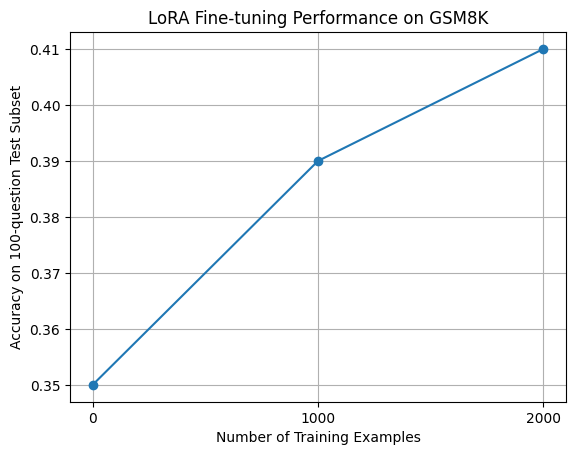

In [29]:
# Part B.7 (continued)

# putting the numbers I got instead of using variables so I don't have to
# recalculate everything and run the whole notebook again
y_values = [0.3500, 0.3900, 0.4100]
x_values = [0, 1000, 2000]
plt.plot(x_values, y_values, marker="o")
plt.title("LoRA Fine-tuning Performance on GSM8K")
plt.xlabel("Number of Training Examples")
plt.ylabel("Accuracy on 100-question Test Subset")
plt.xticks(x_values)
plt.grid()

 - We observe what we hypothesized: there is a smaller gain in accuracy between 1,000 and 2,000 examples than there is between 0 and 1,000 examples.
 - This confirms that there is a law of diminishing returns in data scaling for SFT and that simply increasing the number of examples is not always worth it.

In [38]:
lora_model_2000, lora_tokenizer_2000 = load_math_model(lora_path=lora_adapter_path_2000)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [39]:
# Part B.8

# compare the base model (the 0-example model) with the 2000-example model
# on the same 3 failure examples from Part B.2, showing both responses

base_model, base_tokenizer = load_math_model()
failure_questions = [ex["question"] for ex in incorrect_examples]
base_responses = generate_math(base_model, base_tokenizer, failure_questions, system_prompt=SYSTEM_PROMPT, batch_size=3)
lora_responses = generate_math(lora_model_2000, lora_tokenizer_2000, failure_questions, system_prompt=SYSTEM_PROMPT, batch_size=3)
for i, ex in enumerate(incorrect_examples, 1):
    print(f"Example {i}: --------------------------------------------------------------")
    print(f"Question: {ex['question']}")
    print(f"Ground truth answer: {ex['ground_truth']}\n")
    print(f"Base model response:\n{base_responses[i-1]}\n")
    print(f"LoRA fine-tuned model response:\n{lora_responses[i-1]}\n")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Example 1: --------------------------------------------------------------
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Ground truth answer: 18

Base model response:
To solve this problem, we need to follow these steps:

Step 1: Calculate the total number of eggs laid by Janet's ducks per day.
Total eggs = Eggs per day * Days per week
= 16 * 7
= 112

Step 2: Subtract the number of eggs eaten by Janet for breakfast from the total number of eggs laid.
Eggs left after breakfast = Total eggs - Eggs eaten for breakfast
= 112 - 3
= 109

Step 3: Subtract the number of eggs used to bake muffins for her friends from the remaining eggs.
Eggs left after baking = E ggs left after breakfast - Eggs baked for friends
= 109 - 4
= 105

Step 4: Add the number of 

The SFT model does fix the error from Example 3 and writes the solution in a much cleaner and clearer fashion. However, there are still errors in Examples 1 and 2, but different from the errors seen previously using the base model.

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
!cp -r /content/m146_outputs /content/drive/MyDrive/

In [52]:
# Part B.9

# identify 2 examples where the 2000-example SFT model still fails
lora_2000_incorrect = [r for r in gsm_lora_results_2000["records"] if not r["correct"]][:2]
for i, ex in enumerate(lora_2000_incorrect, 1):
    print(f"Example {i}: --------------------------------------------------------------")
    print(f"Question: {ex['question']}")
    print(f"Ground truth answer: {ex['ground_truth']}\n")
    print(f"LoRA fine-tuned model response:\n{ex['model_response']}\n")

Example 1: --------------------------------------------------------------
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Ground truth answer: 18

LoRA fine-tuned model response:
First find how many eggs Janet eats for breakfast by multiplying the number of eggs per day by the number of eggs eaten per day: 16 eggs/day * 3 eggs/day = 48 eggs/day
Then subtract that amount from the total number of eggs to find out how many are left over: 16 eggs/day - 4 eggs/day = 12 eggs/day
Then multiply the number of leftover eggs by the price per egg to find out how much money she makes: 12 eggs/day * $2/egg = $<<12*2=24>>24

\boxed{24}

Example 2: --------------------------------------------------------------
Question: Josh decides to try flipping a house.  He b

The fine-tuned model still struggles with comprehension and multi-step reasoning, as these problems are translated into incorrect operations and the variables are not tracked correctly between steps. Although it successfully learned how to format its answers, it does not know the logic required to actually understand and solve the math problems.

### B.10-B.11 Few-Shot Prompting


In [31]:
def few_shot_messages_from_train(train_split, indices=(0, 1, 2)):
    messages = []
    for idx in indices:
        ex = train_split[int(idx)]
        reasoning = ex["answer"].split("####")[0].strip()
        final = extract_gt(ex["answer"])
        messages.append({"role": "user", "content": ex["question"]})
        messages.append({"role": "assistant", "content": f"{reasoning}\n\n\\boxed{{{final}}}"})
    return messages

For B.10, build one fixed set of 3 GSM8K training examples and use it for both the base model and the 2k LoRA model. Then compare zero-shot and 3-shot accuracy.

In [42]:
SYSTEM_PROMPT_FEW_SHOT = """
Task: Solve the arithmetic word problem below.
Requirements:
 - Numbered Steps: Clearly list each step using LaTeX for all math.
 - Explanations: Explain the operation and the logic behind each step.
 - Accuracy: Internally verify each calculation using inverse operations (do not show this verification in the final output).

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}
""".strip()

In [43]:
if "math_model" not in globals() or "math_tokenizer" not in globals():
    math_model, math_tokenizer = load_math_model()

if "lora_model_2000" not in globals() or "lora_tokenizer_2000" not in globals():
    lora_model_2000, lora_tokenizer_2000 = load_math_model(lora_path=lora_adapter_path_2000)

# Build one fixed set of 3 GSM8K training examples
few_shot_examples = few_shot_messages_from_train(gsm8k["train"], indices=(0, 1, 2))

# Evaluate the base model with few-shot prompting
base_model_3shot_results = evaluate_gsm8k(
    math_model,
    math_tokenizer,
    gsm8k_test_100,
    system_prompt=SYSTEM_PROMPT,
    few_shot_messages=few_shot_examples,
    batch_size=16,
    output_name="gsm_base_3shot.json",
)

# Evaluate the 2k LoRA model with few-shot prompting
lora_model_2000_3shot_results = evaluate_gsm8k(
    lora_model_2000,
    lora_tokenizer_2000,
    gsm8k_test_100,
    system_prompt=SYSTEM_PROMPT,
    few_shot_messages=few_shot_examples,
    batch_size=16,
    output_name="gsm_lora_2000_3shot.json",
)

print("Comparison of Zero-shot vs. 3-shot Accuracy:")
print(f"Base Model Zero-shot Accuracy: {gsm_results['accuracy']:.4f}")
print(f"Base Model 3-shot Accuracy: {base_model_3shot_results['accuracy']:.4f}")
print(f"LoRA 2k Model Zero-shot Accuracy: {gsm_lora_results_2000['accuracy']:.4f}")
print(f"LoRA 2k Model 3-shot Accuracy: {lora_model_2000_3shot_results['accuracy']:.4f}")

Comparison of Zero-shot vs. 3-shot Accuracy:
Base Model Zero-shot Accuracy: 0.3500
Base Model 3-shot Accuracy: 0.3200
LoRA 2k Model Zero-shot Accuracy: 0.4100
LoRA 2k Model 3-shot Accuracy: 0.4400


In [53]:
print("Few-shot vs. Zero-shot Accuracy Comparison:")

base_zero_shot_accuracy = gsm_results['accuracy']
base_3_shot_accuracy = base_model_3shot_results['accuracy']
base_improvement = base_3_shot_accuracy - base_zero_shot_accuracy

lora_zero_shot_accuracy = gsm_lora_results_2000['accuracy']
lora_3_shot_accuracy = lora_model_2000_3shot_results['accuracy']
lora_improvement = lora_3_shot_accuracy - lora_zero_shot_accuracy

print(f"Base Model Zero-shot Accuracy: {base_zero_shot_accuracy:.4f}")
print(f"Base Model 3-shot Accuracy: {base_3_shot_accuracy:.4f}")
print(f"Base Model Improvement (Delta): {base_improvement:.4f}")
print("---------------------------------------------------")
print(f"LoRA 2k Model Zero-shot Accuracy: {lora_zero_shot_accuracy:.4f}")
print(f"LoRA 2k Model 3-shot Accuracy: {lora_3_shot_accuracy:.4f}")
print(f"LoRA 2k Model Improvement (Delta): {lora_improvement:.4f}")

Few-shot vs. Zero-shot Accuracy Comparison:
Base Model Zero-shot Accuracy: 0.3500
Base Model 3-shot Accuracy: 0.3200
Base Model Improvement (Delta): -0.0300
---------------------------------------------------
LoRA 2k Model Zero-shot Accuracy: 0.4100
LoRA 2k Model 3-shot Accuracy: 0.4400
LoRA 2k Model Improvement (Delta): 0.0300


In [54]:
# Part B.11
# See the below Markdown cell.

 - Few-shot helps the base model significantly due to having clear structured examples for it to understand from.
 - The 2k model gains the most from few shot because it was trained on the practice examples, and thus has a basis to go off of with the few-shot model, as opposed to the base model which may try to imitate the few shot examples without any sort of proper mathematical reasoning.
 - Thus, the base model doesn't actually gain a benefit from few shot and actually goes down, unlike the 2k model which grows in accuracy by 0.03 by having these examples to base its reasoning off of.

### Bonus: Prompt Playground

For the bonus, start from the original prompt, then write your own prompt variants. You do not need to stop at three trials if you want to keep experimenting.


In [44]:
# Keep PROMPT_0 as the old prompt. Fill in PROMPT_1, PROMPT_2, PROMPT_3 yourself.
PROMPT_0 = SYSTEM_PROMPT

PROMPT_1 = """Solve the following arithmetic word problem.
Show your work and clearly indicate your final answer.

Question: {question}
""".strip()

PROMPT_2 = """
Role: You are an expert mathematical logician and tutor.
Task: Solve the arithmetic word problem below.

Requirements:
Reasoning Phase: You must first think through the problem step-by-step inside <thinking> tags. In this block, explicitly state the knowns, write out the necessary equations first, and then solve them.
Final Output: After the <thinking> block, provide the final, clean numbered steps.
Math Formatting: Use LaTeX for all inline math and equations.
Accuracy: Double-check your arithmetic before writing the final steps.

Output Template:
<thinking>
[List of knowns and equations]
[Your step-by-step logic, calculations, and reverse-math verification go here]
</thinking>

Step 1: [Explanation] -> [Math]
Step 2: [Explanation] -> [Math]

Question: {question}
""".strip()

PROMPT_3 = """Solve the given arithmetic word problem, and return the correct answer alongside your reasoning.
Number your steps clearly.
For each step you take, show your work in the following format:
[Verbal explanation for the step] -> mathematical equation, leading to the intermediary answer
These steps should be clear and readable, allowing for worked to be checked later.
Each step should be short and concise, rather than combining many operations at once.

After finding a final answer, show your work for doing the reverse to end up with the original value,
thus checking your work in the process. If it disagrees with the given values, redo the problem.
When checking your work, format it by giving it the following tags: <checking work> <checking work>

Final answer rule:
The last line of your response must be exactly:
\\boxed{ANSWER}

Question: {question}
""".strip()

def evaluate_one_prompt(model, tokenizer, prompt, name="prompt", n=50):
    result = evaluate_gsm8k(
        model,
        tokenizer,
        gsm8k["test"].select(range(n)),
        num_samples=n,
        system_prompt=prompt,
        batch_size=16,
    )
    return {"prompt_name": name, "accuracy": result["accuracy"], "correct": result["correct"], "total": result["total"]}, result

In [45]:
# Baseline bonus run using the old prompt. After this, run your own prompt variants.
if "math_model" not in globals() or "math_tokenizer" not in globals():
    math_model, math_tokenizer = load_math_model()

In [46]:
baseline_row, baseline_result = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_0, name="old_prompt")

In [47]:
prompt1_row, prompt1_result = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_1, name="prompt1")

In [48]:
prompt2_row, prompt2_result = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_2, name="prompt2")

In [49]:
prompt3_row, prompt3_result = evaluate_one_prompt(math_model, math_tokenizer, PROMPT_3, name="prompt3")

In [50]:
print("Accuracies of different prompts: ")
for row in [baseline_row, prompt1_row, prompt2_row, prompt3_row]:
    print(f"{row['prompt_name']}: {row['accuracy']:.4f}")

Accuracies of different prompts: 
old_prompt: 0.2600
prompt1: 0.4000
prompt2: 0.2400
prompt3: 0.3000


In [55]:
# Part B.12
# See below Markdown cell for analysis.

 - Prompt 1 was the simplest and most direct instruction and this is likely why it did better the others at 40% accuracy.
 - Prompt 2 likely performed the worst (24%) because its complex constraints, like forcing LaTeX, <thinking> tags, and rigid templates, likely overwhelmed the model and negatively impacted its reasoning capabilities.
 - Prompt 3 improved over the baseline by enforcing a clear step-by-step reasoning structure, but the "checking work" requirement likely introduced confusion unnecessarily.
 - Ultimately, the prompt variations heavily affected the model's reasoning quality and output format and showed that for smaller base models, overly complex formatting rules distract from the core mathematical logic.